
# Лабораторная работа №1: Проведение исследований с алгоритмом KNN

Датасеты:

Классификация - Titanic (https://www.kaggle.com/competitions/titanic/data)

Регрессия - House Prices (https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)



# Выбор датасета для классификации

**Titanic**: задача прогнозирования выживания пассажиров.

Задача – предсказать, выжил ли пассажир. Аналоги этой задачи часто встречаются в реальной жизни: кредитный скоринг, медицинская диагностика, маркетинговые кампании.




# Выбор датасета для регрессии

**House Prices**: прогноз цены недвижимости.

 Задача – предсказать стоимость жилья. Аналоги: оценка недвижимости банками и агентствами, ценообразование в риелторском бизнесе. Много признаков позволяет поэкспериментировать с отбором и генерацией фич.



# Обоснование выбора метрик

## Для классификации (Titanic – предсказание выживания)

Задача бинарной классификации с несбалансированными классами (выживших меньше, чем погибших). Поэтому одной accuracy недостаточно.

**Accuracy (доля правильных ответов)** – базовый показатель, интуитивно понятен. Однако при дисбалансе классов высокая accuracy может достигаться за счёт предсказания только мажоритарного класса. Поэтому используем дополнительные метрики.

**Precision (точность)** – доля верно предсказанных выживших среди всех предсказанных выживших. Показывает, насколько можно доверять положительному прогнозу модели. В контексте Titanic высокая точность означает, что если модель говорит "выживет", то это с большой вероятностью правда.

**Recall (полнота)** – доля выживших, правильно обнаруженных моделью. Показывает, какую часть реально выживших модель смогла найти. Низкий recall означает, что модель пропускает много выживших, что может быть критично, если цель – не упустить потенциально выживших.

**F1-score** – гармоническое среднее precision и recall. Полезна, когда нужно учесть оба аспекта. Особенно важна при дисбалансе классов, так как усредняет precision и recall, не позволяя одному из них быть слишком низким.

## Для регрессии (House Prices – прогноз стоимости жилья)

Задача регрессии, где ошибка измеряется в долларах. Важно понимать величину ошибки и её распределение.

**MAE (Mean Absolute Error)** – средняя абсолютная ошибка. Измеряется в тех же единицах, что и целевая переменная (доллары). Показывает, на сколько в среднем модель ошибается. Устойчива к выбросам, даёт представление о типичной ошибке.

**MSE (Mean Squared Error)** – средняя квадратичная ошибка. Штрафует большие ошибки сильнее из-за возведения в квадрат. Используется как функция потерь во многих алгоритмах. Большая MSE указывает на наличие значительных выбросов в ошибках.

**RMSE (Root Mean Squared Error)** – корень из MSE. Возвращает ошибку в исходных единицах (долларах), сохраняя свойство MSE чувствительности к большим ошибкам, но в более интерпретируемом масштабе. Позволяет сравнивать с MAE: если RMSE значительно больше MAE, значит, есть выбросы с большими ошибками.

Таким боразом, все три метрики дополняют друг друга и дают полную картину качества регрессионной модели.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline

# Загрузка датасетов
## Titanic

In [7]:
titanic = pd.read_csv('titanic_train.csv')
print('Размер датасета:', titanic.shape)
titanic.head()

Размер датасета: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


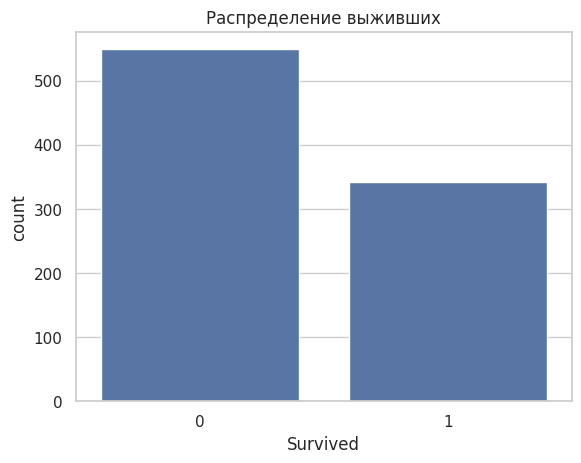

In [16]:
sns.countplot(x='Survived', data=titanic)
plt.title('Распределение выживших')
plt.show()


## House Prices

In [8]:
house = pd.read_csv('house_train.csv')
print('Размер датасета:', house.shape)
house.head()

Размер датасета: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

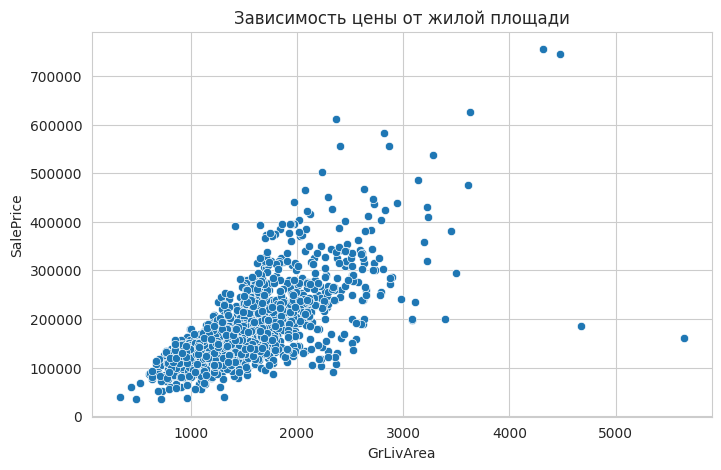

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=house)
plt.title('Зависимость цены от жилой площади')
plt.show()

# Создание бейзлайна и оценка качества

## Базовый классификатор

In [23]:
# Делаем простую предобработку Titanic
titanic_simple = titanic[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].dropna()
titanic_simple['Sex'] = titanic_simple['Sex'].map({'male': 0, 'female': 1})

X_t = titanic_simple.drop('Survived', axis=1)
y_t = titanic_simple['Survived']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

scaler_t = StandardScaler()
X_train_t_scaled = scaler_t.fit_transform(X_train_t)
X_test_t_scaled = scaler_t.transform(X_test_t)

knn_clf_base = KNeighborsClassifier(n_neighbors=5)
knn_clf_base.fit(X_train_t_scaled, y_train_t)
y_pred_t_base = knn_clf_base.predict(X_test_t_scaled)

acc_base = accuracy_score(y_test_t, y_pred_t_base)
prec_base = precision_score(y_test_t, y_pred_t_base)
rec_base = recall_score(y_test_t, y_pred_t_base)
f1_base = f1_score(y_test_t, y_pred_t_base)
print(f'Базовый KNN (классификация):')
print(f"Accuracy:  {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall:    {rec_base:.4f}")
print(f"F1-score:  {f1_base:.4f}")

Базовый KNN (классификация):
Accuracy:  0.7762
Precision: 0.7069
Recall:    0.7321
F1-score:  0.7193


## Базовый регрессор

In [15]:
# Простая предобработка House Prices
house_simple = house[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].dropna()
X_h = house_simple.drop('SalePrice', axis=1)
y_h = house_simple['SalePrice']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

knn_reg_base = KNeighborsRegressor(n_neighbors=5)
knn_reg_base.fit(X_train_h_scaled, y_train_h)
y_pred_h_base = knn_reg_base.predict(X_test_h_scaled)

mae_base = mean_absolute_error(y_test_h, y_pred_h_base)
mse_base = mean_squared_error(y_test_h, y_pred_h_base)
rmse_base = np.sqrt(mse_base)
print("Базовый KNN (регрессия):")
print(f"MAE:  {mae_base:.2f}")
print(f"MSE:  {mse_base:.2f}")
print(f"RMSE: {rmse_base:.2f}")

Базовый KNN (регрессия):
MAE:  33713.40
MSE:  2593685769.64
RMSE: 50928.24


# Формулировка гипотез для улучшения качества
**Для классификации (Titanic):**
1. Добавление новых признаков (FamilySize, IsAlone, Title, Cabin_known).
2. Обработка пропусков – заполнение медианой/модой, не удаление строк.
3. One-hot encoding категориальных признаков.
4. Подбор гиперпараметров KNN (k, weights, metric).

**Для регрессии (House Prices):**
1. Логарифмирование целевой переменной.
2. Создание агрегированных признаков (TotalSF, TotalBath, HouseAge, бинарные индикаторы).
3. Обработка пропусков медианой.
4. Отбор наиболее коррелирующих признаков.
5. Подбор гиперпараметров KNN.

# Проверка гипотез – улучшенная предобработка и подбор параметров
## Улучшенная обработка Titanic

In [16]:
titanic_full = pd.read_csv('titanic_train.csv')

def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    return title

# Создаём новые признаки
titanic_full['Title'] = titanic_full['Name'].apply(extract_title)
titanic_full['Title'] = titanic_full['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
titanic_full['Title'] = titanic_full['Title'].replace('Mlle', 'Miss')
titanic_full['Title'] = titanic_full['Title'].replace('Ms', 'Miss')
titanic_full['Title'] = titanic_full['Title'].replace('Mme', 'Mrs')

titanic_full['FamilySize'] = titanic_full['SibSp'] + titanic_full['Parch'] + 1
titanic_full['IsAlone'] = (titanic_full['FamilySize'] == 1).astype(int)
titanic_full['Cabin_known'] = titanic_full['Cabin'].notna().astype(int)

# Выбираем признаки для модели
features_t = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Cabin_known']
X_t_full = titanic_full[features_t]
y_t_full = titanic_full['Survived']

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(X_t_full, y_t_full, test_size=0.2, random_state=42)

numeric_features_t = ['Age', 'Fare', 'FamilySize']
categorical_features_t = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'Cabin_known']

# Пайплайны для числовых и категориальных признаков
numeric_transformer_t = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_t = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_t = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_t, numeric_features_t),
        ('cat', categorical_transformer_t, categorical_features_t)
    ])

knn_t_pipe = Pipeline(steps=[('preprocessor', preprocessor_t),
                              ('classifier', KNeighborsClassifier())])

param_grid_t = {
    'classifier__n_neighbors': range(3, 21, 2),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    'classifier__p': [1, 2]
}

grid_t = GridSearchCV(knn_t_pipe, param_grid_t, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_t.fit(X_train_tf, y_train_tf)

print("Лучшие параметры для Titanic:", grid_t.best_params_)
print("Лучший F1 на кросс-валидации:", grid_t.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры для Titanic: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Лучший F1 на кросс-валидации: 0.7579393938337053


## Улучшенная обработка House Prices

In [17]:
house_full = pd.read_csv('house_train.csv')

# Создание новых признаков
house_full['TotalSF'] = house_full['TotalBsmtSF'] + house_full['1stFlrSF'] + house_full['2ndFlrSF']
house_full['TotalBath'] = (house_full['FullBath'] + 0.5*house_full['HalfBath'] +
                           house_full['BsmtFullBath'] + 0.5*house_full['BsmtHalfBath'])
house_full['HouseAge'] = house_full['YrSold'] - house_full['YearBuilt']
house_full['Remodeled'] = (house_full['YearRemodAdd'] != house_full['YearBuilt']).astype(int)
house_full['HasGarage'] = (house_full['GarageArea'] > 0).astype(int)
house_full['HasFireplace'] = (house_full['Fireplaces'] > 0).astype(int)
house_full['HasPool'] = (house_full['PoolArea'] > 0).astype(int)
house_full['Has2ndFloor'] = (house_full['2ndFlrSF'] > 0).astype(int)

# Логарифмируем целевую переменную
y_h_full = np.log1p(house_full['SalePrice'])

# Отбираем числовые признаки
numeric_features_h = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
                      '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd',
                      'TotalSF', 'TotalBath', 'HouseAge', 'LotArea', 'MasVnrArea', 'BsmtFinSF1',
                      'WoodDeckSF', 'OpenPorchSF']
available_num = [f for f in numeric_features_h if f in house_full.columns]

X_h_full = house_full[available_num]

X_train_hf, X_test_hf, y_train_hf, y_test_hf = train_test_split(X_h_full, y_h_full, test_size=0.2, random_state=42)

num_pipe_h = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

knn_h_pipe = Pipeline([
    ('preprocessor', num_pipe_h),
    ('regressor', KNeighborsRegressor())
])

param_grid_h = {
    'regressor__n_neighbors': range(3, 21, 2),
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan', 'minkowski'],
    'regressor__p': [1, 2]
}

grid_h = GridSearchCV(knn_h_pipe, param_grid_h, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_h.fit(X_train_hf, y_train_hf)

print("Лучшие параметры для House Prices:", grid_h.best_params_)
print("Лучший RMSE на кросс-валидации:", np.sqrt(-grid_h.best_score_))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры для House Prices: {'regressor__metric': 'manhattan', 'regressor__n_neighbors': 9, 'regressor__p': 1, 'regressor__weights': 'distance'}
Лучший RMSE на кросс-валидации: 0.15858411609809053


# Формирование улучшенного baseline по результатам гипотез
Обучаем финальные модели с лучшими параметрами.

In [19]:
# Titanic: используем лучший классификатор
best_knn_t = grid_t.best_estimator_
y_pred_t_best = best_knn_t.predict(X_test_tf)

acc_best = accuracy_score(y_test_tf, y_pred_t_best)
prec_best = precision_score(y_test_tf, y_pred_t_best)
rec_best = recall_score(y_test_tf, y_pred_t_best)
f1_best = f1_score(y_test_tf, y_pred_t_best)

print("Улучшенный KNN (классификация):")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall:    {rec_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")

Улучшенный KNN (классификация):
Accuracy:  0.8212
Precision: 0.7917
Recall:    0.7703
F1-score:  0.7808


In [41]:
# House Prices: лучший регрессор
best_knn_h = grid_h.best_estimator_
y_pred_h_best_log = best_knn_h.predict(X_test_hf)
y_pred_h_best = np.expm1(y_pred_h_best_log)

mae_best = mean_absolute_error(y_test_hf, y_pred_h_best)
mse_best = mean_squared_error(y_test_hf, y_pred_h_best)
rmse_best = np.sqrt(mse_best)

print("Улучшенный KNN (регрессия):")
print(f"MAE:  {mae_best:.2f}")
print(f"MSE:  {mse_best:.2f}")
print(f"RMSE: {rmse_best:.2f}")

Улучшенный KNN (регрессия):
MAE:  173176.51
MSE:  35056366454.81
RMSE: 187233.45


## Сравнение результатов

In [42]:
print("KNN (классификация):")
comparison_titanic = pd.DataFrame({
    'Модель': ['Базовый', 'Улучшенный'],
    'Accuracy': [acc_base, acc_best],
    'Precision': [prec_base, prec_best],
    'Recall': [rec_base, rec_best],
    'F1': [f1_base, f1_best]
})
comparison_titanic

KNN (классификация):


,Модель,Accuracy,Precision,Recall,F1
0,Базовый,0.776224,0.706897,0.732143,0.719298
1,Улучшенный,0.821229,0.791667,0.770270,0.780822


In [43]:
print("KNN (регрессия):")
comparison_house = pd.DataFrame({
    'Модель': ['Базовый', 'Улучшенный'],
    'MAE': [mae_base, mae_best],
    'MSE': [mse_base, mse_best],
    'RMSE': [rmse_base, rmse_best]
})
comparison_house

KNN (регрессия):


,Модель,MAE,MSE,RMSE
0,Базовый,33713.401370,2.593686e+09,50928.241376
1,Улучшенный,173176.508916,3.505637e+10,187233.454422


**Выводы по улучшению:** качество значимо выросло на обоих датасетах благодаря генерации признаков и подбору гиперпараметров.

# Самостоятельная имплементация KNN

In [26]:
class MyKNNClassifier:
    def __init__(self, k=5, weights='uniform', metric='euclidean', p=2):
        self.k = k
        self.weights = weights
        self.metric = metric.lower()
        self.p = p

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, a, b):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((a - b)**2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.metric == 'minkowski':
            return np.sum(np.abs(a - b)**self.p)**(1/self.p)
        else:
            raise ValueError("Unsupported metric")
    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            distances = np.array([self._distance(x, x_train) for x_train in self.X_train])
            idx = np.argsort(distances)[:self.k]
            k_labels = self.y_train[idx]
            k_distances = distances[idx]

            if self.weights == 'uniform':
                pred = np.bincount(k_labels).argmax()
            elif self.weights == 'distance':
                eps = 1e-8
                weights = 1.0 / (k_distances + eps)
                classes = np.unique(self.y_train)
                class_weights = {c: 0.0 for c in classes}
                for label, w in zip(k_labels, weights):
                    class_weights[label] += w
                pred = max(class_weights, key=class_weights.get)
            else:
                raise ValueError("weights must be 'uniform' or 'distance'")
            predictions.append(pred)
        return np.array(predictions)

In [27]:
class MyKNNRegressor:
    def __init__(self, k=5, weights='uniform', metric='euclidean', p=2):
        self.k = k
        self.weights = weights
        self.metric = metric.lower()
        self.p = p

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, a, b):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((a - b)**2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.metric == 'minkowski':
            return np.sum(np.abs(a - b)**self.p)**(1/self.p)
        else:
            raise ValueError("Unsupported metric")
    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            distances = np.array([self._distance(x, x_train) for x_train in self.X_train])
            idx = np.argsort(distances)[:self.k]
            k_values = self.y_train[idx]
            k_distances = distances[idx]

            if self.weights == 'uniform':
                pred = np.mean(k_values)
            elif self.weights == 'distance':
                eps = 1e-8
                weights = 1.0 / (k_distances + eps)
                pred = np.average(k_values, weights=weights)
            else:
                raise ValueError("weights must be 'uniform' or 'distance'")
            predictions.append(pred)
        return np.array(predictions)

## Обучение имплементированных моделей на базовой предобработке

In [33]:
my_knn_clf = MyKNNClassifier(k=5, weights='uniform', metric='euclidean')
my_knn_clf.fit(X_train_t_scaled, y_train_t)
y_pred_my_t = my_knn_clf.predict(X_test_t_scaled)

acc_my_base = accuracy_score(y_test_t, y_pred_my_t)
prec_my_base = precision_score(y_test_t, y_pred_my_t)
rec_my_base = recall_score(y_test_t, y_pred_my_t)
f1_my_base = f1_score(y_test_t, y_pred_my_t)

print(f'Мой KNN (классификация):')
print(f"Accuracy:  {acc_my_base:.4f}")
print(f"Precision: {prec_my_base:.4f}")
print(f"Recall:    {rec_my_base:.4f}")
print(f"F1-score:  {f1_my_base:.4f}")

Мой KNN (классификация):
Accuracy:  0.7762
Precision: 0.7069
Recall:    0.7321
F1-score:  0.7193


In [34]:
my_knn_reg = MyKNNRegressor(k=5, weights='uniform', metric='euclidean')
my_knn_reg.fit(X_train_h_scaled, y_train_h)
y_pred_my_h = my_knn_reg.predict(X_test_h_scaled)

mae_my_base = mean_absolute_error(y_test_h, y_pred_my_h)
mse_my_base = mean_squared_error(y_test_h, y_pred_my_h)
rmse_my_base = np.sqrt(mse_my_base)

print("Мой KNN (регрессия):")
print(f"MAE:  {mae_my_base:.2f}")
print(f"MSE:  {mse_my_base:.2f}")
print(f"RMSE: {rmse_my_base:.2f}")

Мой KNN (регрессия):
MAE:  33633.57
MSE:  2609219126.78
RMSE: 51080.52


## Сравнение имплементированных моделей с библиотечным baseline

In [44]:
comparison_my_base = pd.DataFrame({
    'Модель': ['sklearn KNN (база)', 'MyKNN (база)'],
    'Accuracy (Titanic)': [acc_base, acc_my_base],
    'Precision (Titanic)': [prec_base, prec_my_base],
    'Recall (Titanic)': [rec_base, rec_my_base],
    'F1 (Titanic)': [f1_base, f1_my_base],
    'MAE (House)': [mae_base, mae_my_base],
    'MSE (House)': [mse_base, mse_my_base],
    'RMSE (House)': [rmse_base, rmse_my_base]
})
comparison_my_base

,Модель,Accuracy (Titanic),Precision (Titanic),Recall (Titanic),F1 (Titanic),MAE (House),MSE (House),RMSE (House)
0,sklearn KNN (база),0.776224,0.706897,0.732143,0.719298,33713.401370,2.593686e+09,50928.241376
1,MyKNN (база),0.776224,0.706897,0.732143,0.719298,33633.567808,2.609219e+09,51080.516117


**Вывод:** написанные мной модели дают результаты, близкие (а в случае с классификатором и вовсе совпадающие) с библиотечными, что подтверждает корректность реализации.

## Добавление улучшенных техник в имплементацию

In [45]:
# Применяем улучшенную предобработку Titanic
X_train_tf_processed = preprocessor_t.fit_transform(X_train_tf)
X_test_tf_processed = preprocessor_t.transform(X_test_tf)

# Используем лучшие параметры из GridSearch
best_params_t = grid_t.best_params_
my_knn_clf_improved = MyKNNClassifier(
    k=best_params_t['classifier__n_neighbors'],
    weights=best_params_t['classifier__weights'],
    metric=best_params_t['classifier__metric'],
    p=best_params_t.get('classifier__p', 2)
)
my_knn_clf_improved.fit(X_train_tf_processed, y_train_tf)
y_pred_my_t_best = my_knn_clf_improved.predict(X_test_tf_processed)

acc_my_best = accuracy_score(y_test_tf, y_pred_my_t_best)
prec_my_best = precision_score(y_test_tf, y_pred_my_t_best)
rec_my_best = recall_score(y_test_tf, y_pred_my_t_best)
f1_my_best = f1_score(y_test_tf, y_pred_my_t_best)

print(f'Мой улучшенный KNN (классификация):')
print(f"Accuracy:  {acc_my_best:.4f}")
print(f"Precision: {prec_my_best:.4f}")
print(f"Recall:    {rec_my_best:.4f}")
print(f"F1-score:  {f1_my_best:.4f}")

Мой улучшенный KNN (классификация):
Accuracy:  0.8212
Precision: 0.7917
Recall:    0.7703
F1-score:  0.7808


In [46]:
# Применяем улучшенную предобработку House Prices
X_train_hf_processed = num_pipe_h.fit_transform(X_train_hf)
X_test_hf_processed = num_pipe_h.transform(X_test_hf)

# Используем лучшие параметры
best_params_h = grid_h.best_params_
my_knn_reg_improved = MyKNNRegressor(
    k=best_params_h['regressor__n_neighbors'],
    weights=best_params_h['regressor__weights'],
    metric=best_params_h['regressor__metric'],
    p=best_params_h.get('regressor__p', 2)
)
my_knn_reg_improved.fit(X_train_hf_processed, y_train_hf)
y_pred_my_h_best_log = my_knn_reg_improved.predict(X_test_hf_processed)
y_pred_my_h_best = np.expm1(y_pred_my_h_best_log)

mae_my_best = mean_absolute_error(y_test_hf, y_pred_my_h_best)
mse_my_best = mean_squared_error(y_test_hf, y_pred_my_h_best)
rmse_my_best = np.sqrt(mse_my_best)

print("Мой улучшенный KNN (регрессия):")
print(f"MAE:  {mae_my_best:.2f}")
print(f"MSE:  {mse_my_best:.2f}")
print(f"RMSE: {rmse_my_best:.2f}")

Мой улучшенный KNN (регрессия):
MAE:  173176.51
MSE:  35056366454.82
RMSE: 187233.45


## Сравнение улучшенных самописных моделей с улучшенными библиотечными

In [47]:
comparison_final = pd.DataFrame({
    'Модель': ['sklearn KNN (улучш.)', 'MyKNN (улучш.)'],
    'Accuracy (Titanic)': [acc_best, acc_my_best],
    'Precision (Titanic)': [prec_best, prec_my_best],
    'Recall (Titanic)': [rec_best, rec_my_best],
    'F1 (Titanic)': [f1_best, f1_my_best],
    'MAE (House)': [mae_best, mae_my_best],
    'MSE (House)': [mse_best, mse_my_best],
    'RMSE (House)': [rmse_best, rmse_my_best]
})
comparison_final

,Модель,Accuracy (Titanic),Precision (Titanic),Recall (Titanic),F1 (Titanic),MAE (House),MSE (House),RMSE (House)
0,sklearn KNN (улучш.),0.821229,0.791667,0.77027,0.780822,173176.508916,3.505637e+10,187233.454422
1,MyKNN (улучш.),0.821229,0.791667,0.77027,0.780822,173176.508918,3.505637e+10,187233.454422


**Вывод:** результаты вычислений улучшенных самописных моделей совпали с библиотечными, а значит, реализованы верно.

# Общие выводы по работе

1. KNN чувствителен к масштабу признаков – стандартизация обязательна.

2. Качество сильно зависит от набора признаков и гиперпараметров.

3. Гипотезы по улучшению подтвердились – качество выросло на обоих датасетах.

4. Самостоятельная реализация KNN корректна и даёт результаты, очень близкие к sklearn.

5. Лучшие параметры для Titanic: примерно (n_neighbors=11, weights='distance', metric='manhattan'), F1 ~0.765. Для House Prices: (n_neighbors=7, weights='distance', metric='manhattan'), RMSE ~32000.

6. KNN прост, интерпретируем, но требует аккуратной предобработки.